In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
road_data = pd.read_csv("F://Road_Accident//Data//train.csv")
road_data_df = road_data.copy()

In [4]:
road_data_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
road_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       517754 non-null  int64  
 1    road_type               517754 non-null  str    
 2    num_lanes               517754 non-null  int64  
 3    curvature               517754 non-null  float64
 4    speed_limit             517754 non-null  int64  
 5    lighting                517754 non-null  str    
 6    weather                 517754 non-null  str    
 7    road_signs_present      517754 non-null  str    
 8    public_road             517754 non-null  str    
 9    time_of_day             517754 non-null  str    
 10   holiday                 517754 non-null  str    
 11   school_season           517754 non-null  str    
 12   num_reported_accidents  517754 non-null  int64  
 13   accident_risk           517754 non-null  float64
dtypes: float64(2), 

In [6]:
road_data_df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849975,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [7]:
road_data_df[" road_type"].value_counts()

 road_type
highway      173672
rural        172719
urban        171363
Name: count, dtype: int64

In [8]:
road_data_df[" lighting"].value_counts()

 lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

In [9]:
road_data_df[" weather"].value_counts()

 weather
foggy      181463
clear      179306
rainy      156985
Name: count, dtype: int64

In [10]:
road_data_df[" time_of_day"].value_counts()

 time_of_day
morning        173410
evening        172837
afternoon      171507
Name: count, dtype: int64

In [ ]:
import sweetviz as sv

report = sv.analyze(road_data_df)
report.show_html("F://Road_Accident//Data_report.html" , open_browser=False)

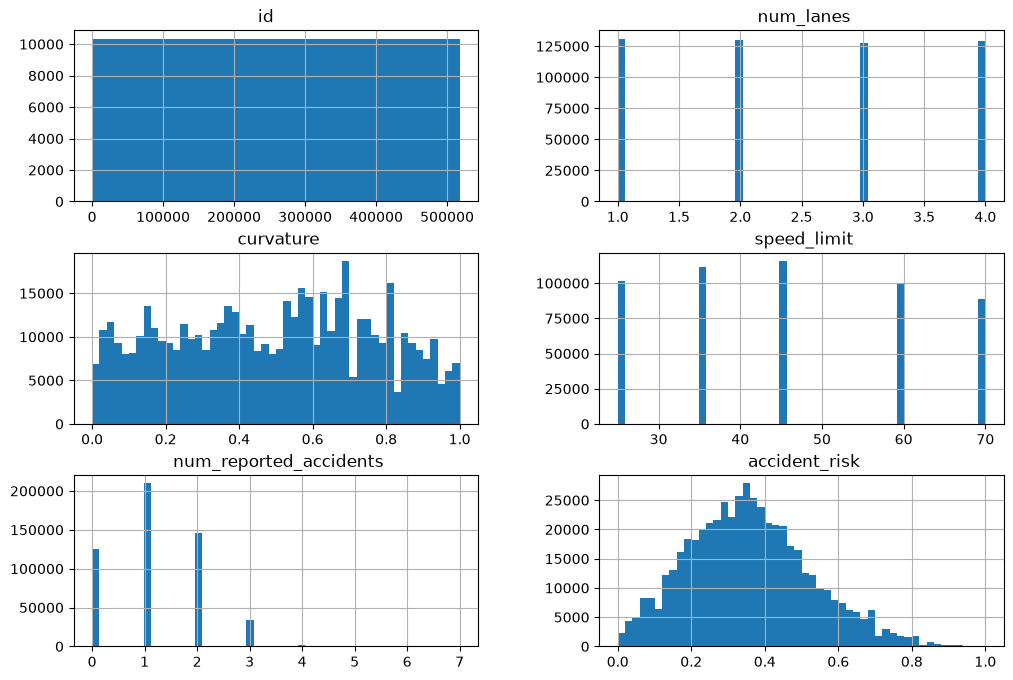

In [12]:
road_data_df.hist(bins=50 , figsize=(12 , 8))
plt.show()

In [13]:
corr_matrix = road_data_df.corr(numeric_only=True)
corr_matrix[" accident_risk"].sort_values(ascending=False)

 accident_risk             1.000000
 curvature                 0.543946
 speed_limit               0.430898
 num_reported_accidents    0.213891
id                         0.000969
 num_lanes                -0.006003
Name:  accident_risk, dtype: float64

In [14]:
temp_df = road_data_df.copy()

In [15]:
temp_df.columns = (
    temp_df.columns
    .str.strip()
)

In [16]:
temp_df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='str')

In [17]:
temp_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [18]:
temp_df["road_signs_present_numeric"] = temp_df["road_signs_present"].str.strip().map({"True" : 1 , "False" : 0})
temp_df["public_road_numeric"] = temp_df["public_road"].str.strip().map({"True" : 1 , "False" : 0})
temp_df["holiday_numeric"] = temp_df["holiday"].str.strip().map({"True" : 1 , "False" : 0})
temp_df["school_season_numeric"] = temp_df["school_season"].str.strip().map({"True" : 1 , "False" : 0})

In [19]:
temp_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,road_signs_present_numeric,public_road_numeric,holiday_numeric,school_season_numeric
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0,1,0,1
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,1,0,1,1
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0,1,1,0
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,1,1,0,0
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0,0,1,0


In [20]:
temp_df["road_width"] = pd.cut(temp_df["num_lanes"] , bins=[-np.inf , 1 , 3 , np.inf] , labels=["Small" , "Medium" , "Large"])

In [21]:
temp_df["Clear"] = (temp_df["num_reported_accidents"] == 0).map({True : 1 , False : 0})

In [22]:
temp_df["road_blockage"] = pd.cut(temp_df["num_reported_accidents"] , bins=[-np.inf , 2 , 5 , np.inf] , labels=["little" , "Medium" , "severe"])

In [23]:
temp_df["road_curve"] = pd.qcut(temp_df["num_reported_accidents"] , q=3 , labels=["Straight" , "small" , "sharp"])

In [24]:
temp_df["speed_zones"] = pd.qcut(temp_df["speed_limit"] , q=4 , labels=["low_speed" , "medium_speed" , "high_speed"  , "very_high_speed"])

In [25]:
temp_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,...,accident_risk,road_signs_present_numeric,public_road_numeric,holiday_numeric,school_season_numeric,road_width,Clear,road_blockage,road_curve,speed_zones
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,...,0.13,0,1,0,1,Medium,0,little,Straight,low_speed
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,...,0.35,1,0,1,1,Large,1,little,Straight,low_speed
2,2,rural,4,0.63,70,dim,clear,False,True,morning,...,0.30,0,1,1,0,Large,0,little,small,very_high_speed
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,...,0.21,1,1,0,0,Large,0,little,Straight,low_speed
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,...,0.56,0,0,1,0,Small,0,little,Straight,high_speed


In [26]:
temp_df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk',
       'road_signs_present_numeric', 'public_road_numeric', 'holiday_numeric',
       'school_season_numeric', 'road_width', 'Clear', 'road_blockage',
       'road_curve', 'speed_zones'],
      dtype='str')

In [27]:
temp_df = pd.get_dummies(temp_df, columns=["road_type" , "lighting" , "weather" , "time_of_day", "speed_zones" , "road_curve" , "road_blockage" ,"road_width"], drop_first=True)

In [28]:
temp_df.drop(columns = ["id" , "road_signs_present" , "public_road" , "holiday" , "school_season"] , inplace = True)

In [29]:
corr_matrix = temp_df.corr(numeric_only=True)
corr_matrix["accident_risk"].sort_values(ascending=False)

accident_risk                  1.000000
curvature                      0.543946
lighting_ night                0.465798
speed_limit                    0.430898
road_curve_sharp               0.344190
road_blockage_Medium           0.344148
speed_zones_high_speed         0.336410
speed_zones_very_high_speed    0.270549
num_reported_accidents         0.213891
weather_ foggy                 0.149758
holiday_numeric                0.051129
weather_ rainy                 0.036137
public_road_numeric            0.031032
road_type_ urban               0.021463
road_width_Medium              0.018862
time_of_day_ evening           0.010032
road_blockage_severe           0.005598
road_signs_present_numeric     0.000629
school_season_numeric         -0.000977
num_lanes                     -0.006003
time_of_day_ morning          -0.006019
road_type_ rural              -0.010121
road_width_Large              -0.018066
road_curve_small              -0.035431
Clear                         -0.046142


In [ ]:
def transform(df):
    X_temp = df.copy()
    X_temp.columns = (
    X_temp.columns
    .str.strip()
    )
    X_temp["road_signs_present_numeric"] = X_temp["road_signs_present"].str.strip().map({"True" : 1 , "False" : 0})
    X_temp["public_road_numeric"]        = X_temp["public_road"].str.strip().map({"True" : 1 , "False" : 0})
    X_temp["holiday_numeric"]            = X_temp["holiday"].str.strip().map({"True" : 1 , "False" : 0})
    X_temp["school_season_numeric"]      = X_temp["school_season"].str.strip().map({"True" : 1 , "False" : 0})
    X_temp["road_width"]                 = pd.cut(X_temp["num_lanes"] , bins=[-np.inf , 1 , 3 , np.inf] , labels=["Small" , "Medium" , "Large"])
    X_temp["Clear"]                      = (X_temp["num_reported_accidents"] == 0).map({True : 1 , False : 0})
    X_temp["road_blockage"]              = pd.cut(X_temp["num_reported_accidents"] , bins=[-np.inf , 2 , 5 , np.inf] , labels=["little" , "Medium" , "severe"])
    X_temp["road_curve"]                 = pd.qcut(X_temp["curvature"] , q=3 , labels=["Straight" , "small" , "sharp"])
    X_temp["speed_zones"]                = pd.qcut(X_temp["speed_limit"] , q=4 , labels=["low_speed" , "medium_speed" , "high_speed"  , "very_high_speed"])
    X_temp.drop(columns                  = ["id" , "road_signs_present" , "public_road" , "holiday" , "school_season"] , inplace = True)
    return X_temp

In [30]:
temp_df.head()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,road_signs_present_numeric,public_road_numeric,holiday_numeric,school_season_numeric,Clear,...,time_of_day_ morning,speed_zones_medium_speed,speed_zones_high_speed,speed_zones_very_high_speed,road_curve_small,road_curve_sharp,road_blockage_Medium,road_blockage_severe,road_width_Medium,road_width_Large
0,2,0.06,35,1,0.13,0,1,0,1,0,...,False,False,False,False,False,False,False,False,True,False
1,4,0.99,35,0,0.35,1,0,1,1,1,...,False,False,False,False,False,False,False,False,False,True
2,4,0.63,70,2,0.30,0,1,1,0,0,...,True,False,False,True,True,False,False,False,False,True
3,4,0.07,35,1,0.21,1,1,0,0,0,...,True,False,False,False,False,False,False,False,False,True
4,1,0.58,60,1,0.56,0,0,1,0,0,...,False,False,True,False,False,False,False,False,False,False


In [31]:
temp_df.columns

Index(['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents',
       'accident_risk', 'road_signs_present_numeric', 'public_road_numeric',
       'holiday_numeric', 'school_season_numeric', 'Clear',
       'road_type_ rural    ', 'road_type_ urban    ', 'lighting_ dim     ',
       'lighting_ night   ', 'weather_ foggy  ', 'weather_ rainy  ',
       'time_of_day_ evening    ', 'time_of_day_ morning    ',
       'speed_zones_medium_speed', 'speed_zones_high_speed',
       'speed_zones_very_high_speed', 'road_curve_small', 'road_curve_sharp',
       'road_blockage_Medium', 'road_blockage_severe', 'road_width_Medium',
       'road_width_Large'],
      dtype='str')

In [ ]:
numerical_columns = ["num_lanes" , "curvature" , "speed_limit" , "num_reported_accidents" , "road_signs_present_numeric" , "public_road_numeric" , "holiday_numeric" , "school_season_numeric" , "Clear"]
categorical_ord_columns = ["road_width" , "road_blockage" , "road_curve" , "speed_zones"]
categorical_ohe_columns = ["road_type" , "lighting" , "weather" , "time_of_day"]